# 2400nm以上で異常挙動を示すベイスギスペクトルの外れ値除去 (SNV基準)

波長 2400nm 以上（波数 ≤ 1e7/2400 ≒ 4166.7 cm⁻¹）の帯域で異常な挙動を示すサンプルを外れ値として除去し、
クリーニング済みデータセットを保存する。

**判定根拠（SNV処理 + EDAで確認）**
- スペクトル列は波数(cm⁻¹)。波長[nm] = 1e7 / 波数。データ範囲は約1000〜2500nm。
- 生スペクトルでは見づらいが、SNV(行標準化)をかけると異常が明瞭になる: 一部サンプルは2400nm付近で
  鋭いスパイク状のピークが立ち、その後急落する（[[snv-epo-strength-pipeline]] の `nir_features.snv` を使用）。
- このエッジスパイクを持つのは **すべてベイスギ**。SNV帯域内の最大値が大きいほど顕著で、最大値>5 の48件は100%ベイスギ。
- ベイスギ内では SNV帯域内最大値が **正常クラスタ ≤2.62 と異常群 ≥2.88 に明確に分離**（間にギャップ）。
  → 閾値 2.75 で頑健に判別。該当 **52件**。
- 注: 帯域内最大値の絶対水準は樹種ごとに異なる(正常でも他樹種は~2.7に達する)ため、判定はベイスギに限定する。

**除去基準**: 樹種=ベイスギ かつ SNV帯域(≥2400nm)内の最大値 > 2.75

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import numpy as np
from nir_features import snv

df = pd.read_csv('../data/train.csv', encoding='cp932')
meta_cols = ['sample number', 'species number', '樹種', '含水率']
wn = df.columns[len(meta_cols):].astype(float).values  # 波数 cm-1
X = df[df.columns[len(meta_cols):]].values.astype(float)
print('波数範囲 cm-1:', wn.min(), wn.max())
print('波長範囲 nm :', 1e7 / wn.max(), 1e7 / wn.min())
print('shape:', df.shape)

波数範囲 cm-1: 3999.82139 9993.76781
波長範囲 nm : 1000.6236076441324 2500.111636234837
shape: (1322, 1559)


In [2]:
# SNV(行標準化)で散乱補正 → 2400nm以上帯域のスパイクで外れ値検出
WL_THRESHOLD_NM = 2400
SNV_MAX_THRESHOLD = 2.75  # ベイスギ正常(<=2.62) と 異常(>=2.88) のギャップ中点

Xs = snv(X)
band_mask = wn <= 1e7 / WL_THRESHOLD_NM
print(f'対象帯域(>= {WL_THRESHOLD_NM}nm)の列数:', int(band_mask.sum()))

band_max = Xs[:, band_mask].max(axis=1)  # 帯域内SNV最大値(エッジスパイクの指標)

# 外れ値: ベイスギ かつ エッジスパイクが大きい
is_outlier = (df['樹種'] == 'ベイスギ') & (band_max > SNV_MAX_THRESHOLD)
print('除去サンプル数:', int(is_outlier.sum()))
print('除去sample number:', sorted(df.loc[is_outlier, 'sample number'].astype(int).tolist()))

# ベイスギ帯域内最大値のソート(ギャップ確認)
b = np.sort(band_max[(df['樹種'] == 'ベイスギ').values])
print('\nベイスギ band_max ソート(境界付近):', np.round(b[55:70], 2))

対象帯域(>= 2400nm)の列数: 44
除去サンプル数: 52
除去sample number: [1556, 1557, 1558, 1559, 1560, 1561, 1562, 1563, 1564, 1565, 1566, 1567, 1568, 1569, 1570, 1571, 1572, 1573, 1574, 1575, 1576, 1577, 1578, 1579, 1580, 1581, 1582, 1583, 1584, 1585, 1586, 1587, 1588, 1589, 1590, 1591, 1592, 1593, 1594, 1595, 1596, 1597, 1598, 1599, 1600, 1601, 1602, 1603, 1604, 1605, 1606, 1607]

ベイスギ band_max ソート(境界付近): [2.58 2.59 2.6  2.61 2.62 2.88 3.15 3.73 4.56 5.3  6.41 7.9  9.06 9.24
 9.45]


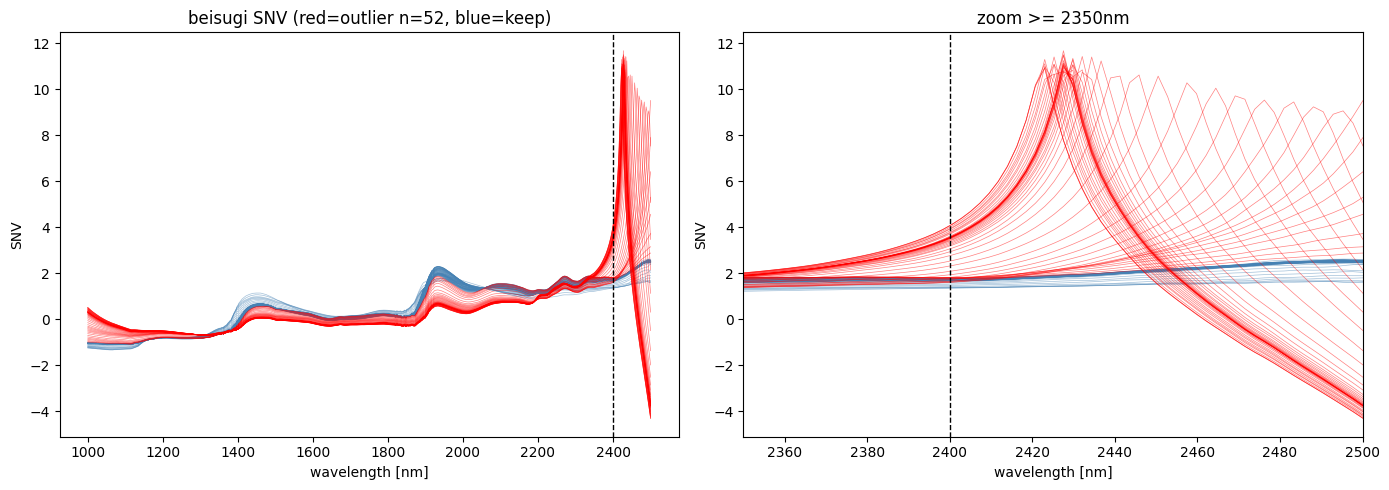

In [3]:
# 除去前後のベイスギSNVスペクトルを可視化して確認
import matplotlib.pyplot as plt

wl = 1e7 / wn
order = np.argsort(wl)
beis = (df['樹種'] == 'ベイスギ').values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in np.where(beis)[0]:
    color = 'red' if is_outlier.iloc[i] else 'steelblue'
    for ax in axes:
        ax.plot(wl[order], Xs[i][order], lw=0.5, alpha=0.5, color=color)
for ax in axes:
    ax.axvline(WL_THRESHOLD_NM, color='k', ls='--', lw=1)
    ax.set_xlabel('wavelength [nm]'); ax.set_ylabel('SNV')
axes[0].set_title(f'beisugi SNV (red=outlier n={int(is_outlier.sum())}, blue=keep)')
axes[1].set_xlim(2350, 2500); axes[1].set_title('zoom >= 2350nm')
plt.tight_layout(); plt.show()

In [4]:
# クリーニング済みデータセットを定義して保存
df_clean = df.loc[~is_outlier].reset_index(drop=True)
print('元データ:', df.shape, '-> クリーニング後:', df_clean.shape)
print('ベイスギ:', int(beis.sum()), '->', int((df_clean['樹種'] == 'ベイスギ').sum()))

out_path = '../data/train_clean.csv'
df_clean.to_csv(out_path, index=False, encoding='cp932')
print('保存:', out_path)

元データ: (1322, 1559) -> クリーニング後: (1270, 1559)
ベイスギ: 112 -> 60


保存: ../data/train_clean.csv
